# 📊Customer Churns

## Introduction

This project analyzes customer churn data to identify the main reasons why customers leave a telecom company.

The analysis shows that customers with month-to-month contracts, high monthly charges, and low tenure are more likely to churn.

This project helps businesses improve customer retention strategies, reduce churn rates, and make better data-driven decisions

## Objectives

- To analyze customer data and identify churn patterns.

- To understand the major reasons why customers leave the company.
  
- To perform data cleaning and preprocessing for accurate analysis.

- To help businesses improve customer retention strategies.



## Import Libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [6]:
df = pd.read_csv('churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



## Data Cleaning

### Convert TotalCharges to Numeric



In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Fill Missing Values

In [26]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

### Convert Churn Column

In [10]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

### Check Null Values

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Feature Understanding

In [12]:
for col in df.columns:
    print(col, ":", df[col].nunique())

customerID : 7043
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


Purpose :
- Understand categorical columns
- Understand numerical columns
- Analyze data diversity

## Exploratory Data Analysis (EDA)
### Overall Churn Rate

In [14]:
churn_rate = df['Churn'].mean() * 100

### Churn by Contract

In [15]:
df.groupby('Contract')['Churn'].mean()*100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

### Churn by Payment Method

In [16]:
df.groupby('PaymentMethod')['Churn'].mean()*100

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

### Monthly Charges vs Churn

In [17]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

### Tenure vs Churn

In [18]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

## Data Visualization

### Churn Count Plot

<Axes: xlabel='Churn', ylabel='count'>

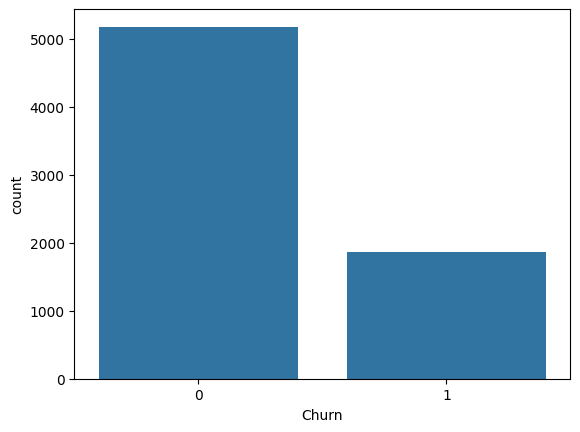

In [19]:
sns.countplot(x='Churn', data=df)

### Contract vs Churn Plot

<Axes: xlabel='Contract', ylabel='count'>

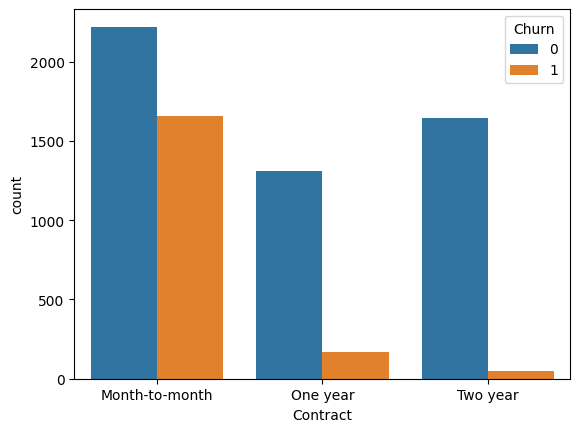

In [20]:
sns.countplot(x='Contract', hue='Churn', data=df)

### Payment Method vs Churn Plot

<Axes: xlabel='PaymentMethod', ylabel='count'>

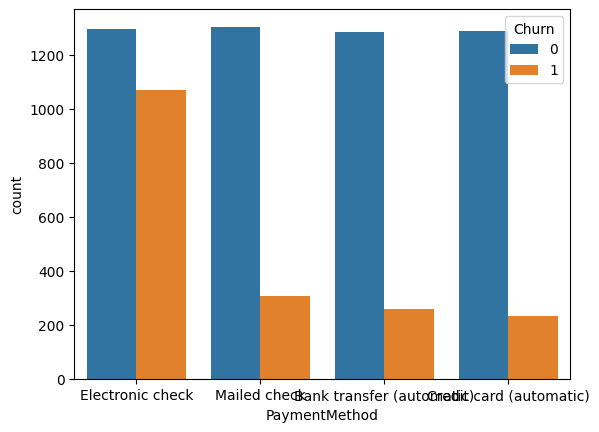

In [21]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

### Monthly Charges Distribution

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

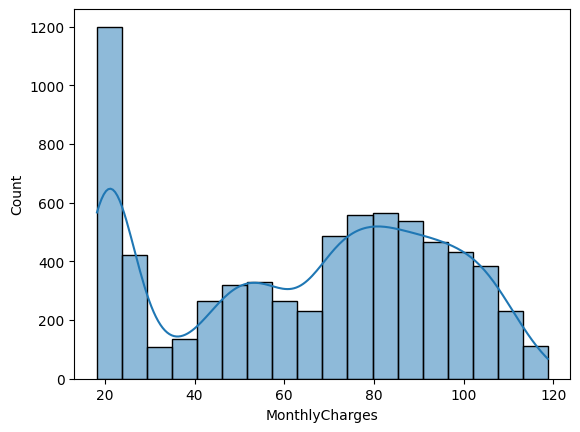

In [22]:
sns.histplot(df['MonthlyCharges'], kde=True)

### Boxplot: Monthly Charges vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

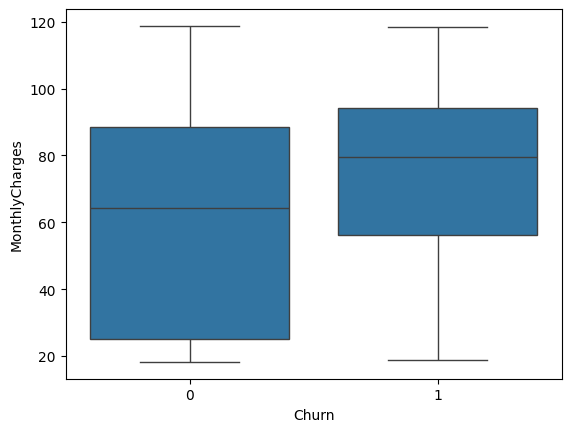

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

### Correlation Heatmap

<Axes: >

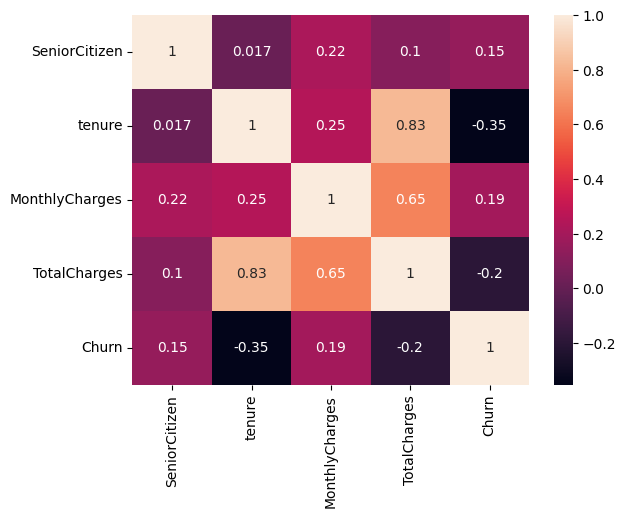

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Conclusion

- This Customer Churn Analysis project helps telecom companies understand customer behavior and identify the major reasons behind customer loss.
- Using data analysis and visualization techniques, businesses can:
       Improve customer retention
       Reduce churn rate
       Increase customer satisfaction
       Build better marketing strategies
       Improve long-term business growth

- The project demonstrates how data analytics can help organizations make data-driven business decisions  

### Recommendations

- Provide special offers and discounts to month-to-month customers to improve retention.
- Reduce customer churn by offering affordable pricing plans for customers with high monthly charges.
- Focus on improving customer experience during the early months of service because low-tenure customers are more likely to leave.
- Encourage customers to switch to long-term contracts for better retention.
- Improve customer support services to increase customer satisfaction and loyalty.
- Analyze payment methods with high churn rates and introduce more convenient payment options.
- Use personalized marketing campaigns for high-risk customers.  